# Task 3 — Random-Walk Tests

This notebook evaluates whether the primary market (SY, CBOT Soybeans) and the secondary market (AUG, SHFE Gold Futures) exhibit random-walk, mean-reverting, or trend-following behavior at different time scales.

Following the project requirements, two diagnostics are used:

1. **Variance-Ratio (VR) Test** — compares the variance of multi-bar returns with the variance implied by a random walk.
2. **Push-Response Test** — examines how prices behave after unusually large positive or negative 5-minute returns.

The cleaned 5-minute datasets produced in Task 2 are used directly. The analysis is conducted over multiple horizons so that short-, medium-, and longer-horizon behavior can be compared.

The objective is not only to classify each market, but also to determine whether the observed time-series behavior provides empirical motivation for the channel-based trend-following strategy implemented in Task 4.

## 1. Setup and Data Loading

### 1.1 Configuration

Task 2 stores the cleaned datasets in `data/clean/<TICKER>.parquet`.  
This notebook loads those cleaned files directly so that the statistical tests use exactly the same validated data as the downstream backtests.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

# Project directories
DATA = Path('data')
CLEAN = DATA / 'clean'
OUT_DIR = Path('task3_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Markets required for Task 3
MARKETS = {
    'SY': {
        'name': 'CBOT Soybeans',
        'role': 'Primary'
    },
    'AUG': {
        'name': 'SHFE Gold Futures',
        'role': 'Secondary'
    }
}

# Test horizons measured in 5-minute bars
HORIZONS = [1, 2, 4, 8, 16, 32, 64, 128]

# Push-event thresholds
POS_Q = 0.90
NEG_Q = 0.10

print('Markets:', list(MARKETS.keys()))
print('Clean data directory:', CLEAN.resolve())
print('Output directory:', OUT_DIR.resolve())

Markets: ['SY', 'AUG']
Clean data directory: /Users/apple/Desktop/期货市场趋势跟踪策略的量化分析与滚动回测/数据/data/clean
Output directory: /Users/apple/Desktop/期货市场趋势跟踪策略的量化分析与滚动回测/数据/task3_outputs


### 1.2 Load cleaned data

The cleaned datasets from Task 2 already contain standardized timestamps, validated OHLC prices, and pre-computed simple and log returns.

Therefore, Task 3 does not repeat the full preprocessing procedure. It only reloads the required markets and performs a small sanity check before running the statistical tests.

In [2]:
def load_clean(ticker: str) -> pd.DataFrame:
    """Load the cleaned market data produced in Task 2."""
    
    path = CLEAN / f'{ticker}.parquet'
    
    if not path.exists():
        raise FileNotFoundError(
            f'{path} not found. Please run Task 2 first.'
        )
    
    df = pd.read_parquet(path).copy()
    df['ts'] = pd.to_datetime(df['ts'])
    
    return df


markets = {}

for ticker in MARKETS:
    markets[ticker] = load_clean(ticker)
    
    print(
        f'{ticker}: '
        f'{len(markets[ticker]):,} rows | '
        f'{markets[ticker]["ts"].min()} → '
        f'{markets[ticker]["ts"].max()}'
    )

SY: 495,740 rows | 1982-07-01 09:35:00 → 2026-04-10 13:15:00
AUG: 138,744 rows | 2018-05-03 09:05:00 → 2026-04-10 15:00:00


## 2. Variance-Ratio Test

### 2.1 Method

The Variance-Ratio (VR) test examines whether multi-period returns behave as they would under a random walk.

For a return series $r_t$, the variance ratio at horizon $q$ is

$$
VR(q)
=
\frac{
\operatorname{Var}\left(r_t+r_{t-1}+\cdots+r_{t-q+1}\right)
}{
q\,\operatorname{Var}(r_t)
}.
$$

Under a random walk,

$$
VR(q) \approx 1.
$$

The interpretation is:

- $VR(q) > 1$: positive serial dependence and a **trend/momentum** tendency.
- $VR(q) < 1$: negative serial dependence and a **mean-reversion** tendency.
- $VR(q) \approx 1$: behavior closer to a **random walk**.

Because a variance ratio can be slightly above or below 1 purely because of sampling variation, statistical significance should also be considered rather than classifying the market solely from the sign of $VR(q)-1$.

The test is evaluated over horizons from 1 to 128 five-minute bars to examine how the behavior changes across time scales.

In [3]:
def variance_ratio(logret: pd.Series, q: int) -> float:
    """
    Compute the variance ratio at horizon q using overlapping q-bar returns.
    
    VR(q) = Var(q-bar return) / [q * Var(1-bar return)]
    """
    
    x = logret.dropna().to_numpy()
    
    if len(x) <= q + 5:
        return np.nan
    
    # Variance of one-bar returns
    var_1 = np.var(x, ddof=1)
    
    if not np.isfinite(var_1) or var_1 <= 0:
        return np.nan
    
    # Overlapping q-bar cumulative returns
    q_returns = (
        pd.Series(x)
        .rolling(q)
        .sum()
        .dropna()
        .to_numpy()
    )
    
    var_q = np.var(q_returns, ddof=1)
    
    return var_q / (q * var_1)

### 2.2 Statistical Significance

A variance ratio above or below 1 does not by itself establish statistically meaningful serial dependence.

To distinguish economically visible deviations from sampling noise, a heteroskedasticity-robust Lo–MacKinlay variance-ratio statistic is also computed.

The null hypothesis is

$$
H_0: VR(q)=1,
$$

which corresponds to random-walk behavior at horizon $q$.

For each horizon:

- a small p-value indicates statistically significant evidence against the random-walk null;
- if the deviation is significant and $VR(q)>1$, the evidence is consistent with positive serial dependence;
- if the deviation is significant and $VR(q)<1$, the evidence is consistent with negative serial dependence;
- if the deviation is not significant, the result is treated as statistically indistinguishable from a random walk at that horizon.

A 5% significance level is used for the main interpretation.

In [4]:
from scipy.stats import norm

In [5]:
def variance_ratio_robust(logret: pd.Series, q: int) -> dict:
    """
    Heteroskedasticity-robust Lo-MacKinlay variance-ratio test.

    Returns:
        variance_ratio : VR(q)
        z_stat         : robust z statistic
        p_value        : two-sided p-value
    """

    x = logret.dropna().to_numpy()
    n = len(x)

    if q <= 1 or n <= q + 5:
        return {
            'variance_ratio': np.nan,
            'z_stat': np.nan,
            'p_value': np.nan
        }

    # Demean one-bar returns
    mu = np.mean(x)
    u = x - mu

    # One-bar variance
    sigma2 = np.sum(u**2) / (n - 1)

    if not np.isfinite(sigma2) or sigma2 <= 0:
        return {
            'variance_ratio': np.nan,
            'z_stat': np.nan,
            'p_value': np.nan
        }

    # Overlapping q-bar cumulative returns
    q_ret = (
        pd.Series(x)
        .rolling(q)
        .sum()
        .dropna()
        .to_numpy()
    )

    # Variance ratio
    var_q = np.var(q_ret, ddof=1)
    vr = var_q / (q * sigma2)

    # Heteroskedasticity-robust variance estimator
    theta = 0.0

    for j in range(1, q):
        product = (u[j:]**2) * (u[:-j]**2)

        delta_j = (
            np.sum(product)
            / (np.sum(u**2) ** 2)
        )

        weight = (2 * (q - j) / q) ** 2
        theta += weight * delta_j

    if theta <= 0 or not np.isfinite(theta):
        z_stat = np.nan
        p_value = np.nan
    else:
        z_stat = (vr - 1.0) / np.sqrt(theta)
        p_value = 2 * norm.sf(abs(z_stat))

    return {
        'variance_ratio': vr,
        'z_stat': z_stat,
        'p_value': p_value
    }

In [6]:
def run_variance_ratio_test(df: pd.DataFrame, horizons) -> pd.DataFrame:
    """
    Run the heteroskedasticity-robust Variance-Ratio test
    across multiple horizons.
    """
    
    rows = []

    for q in horizons:
        result = variance_ratio_robust(df['logret'], q)

        vr = result['variance_ratio']
        z_stat = result['z_stat']
        p_value = result['p_value']

        if np.isnan(vr):
            signal = 'not-applicable'
        elif p_value < 0.05:
            if vr > 1:
                signal = 'trend-following'
            elif vr < 1:
                signal = 'mean-reversion'
            else:
                signal = 'random-walk-like'
        else:
            signal = 'random-walk-like'

        rows.append({
            'horizon_bars': q,
            'horizon_minutes': q * 5,
            'variance_ratio': vr,
            'z_stat': z_stat,
            'p_value': p_value,
            'significant_5pct': (
                False if np.isnan(p_value) else p_value < 0.05
            ),
            'signal': signal
        })

    return pd.DataFrame(rows)

In [7]:
sy_vr = run_variance_ratio_test(
    markets['SY'],
    HORIZONS
)

sy_vr

,horizon_bars,horizon_minutes,variance_ratio,z_stat,p_value,significant_5pct,signal
0,1,5,NaN,NaN,NaN,False,not-applicable
1,2,10,0.976874,-8.203356,2.337674e-16,True,mean-reversion
2,4,20,0.949250,-10.444207,1.557512e-25,True,mean-reversion
3,8,40,0.936978,-9.129852,6.859313e-20,True,mean-reversion
4,16,80,0.939368,-6.625700,3.456063e-11,True,mean-reversion
5,32,160,0.953591,-3.936391,8.271608e-05,True,mean-reversion
6,64,320,0.970335,-1.846562,6.481063e-02,False,random-walk-like
7,128,640,0.977295,-0.972072,3.310146e-01,False,random-walk-like


### 2.3 Soybean Results

The variance-ratio test is first applied to CBOT Soybeans across horizons from 2 to 128 five-minute bars.

The horizontal reference line at $VR=1$ represents the random-walk benchmark. Values below 1 indicate negative serial dependence, while values above 1 indicate positive serial dependence.

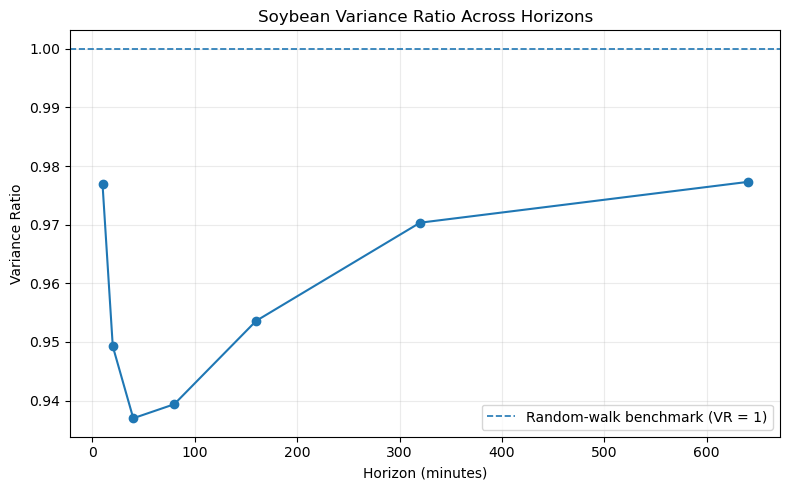

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = sy_vr.dropna(subset=['variance_ratio'])

ax.plot(
    plot_data['horizon_minutes'],
    plot_data['variance_ratio'],
    marker='o'
)

ax.axhline(
    y=1.0,
    linestyle='--',
    linewidth=1.2,
    label='Random-walk benchmark (VR = 1)'
)

ax.set_xlabel('Horizon (minutes)')
ax.set_ylabel('Variance Ratio')
ax.set_title('Soybean Variance Ratio Across Horizons')

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 2.4 Gold Futures Results

The same variance-ratio test is applied to SHFE Gold Futures (AUG) using the identical horizons and statistical significance criteria.

Using the same methodology allows the serial-dependence structure of the primary and secondary markets to be compared directly.

In [9]:
aug_vr = run_variance_ratio_test(
    markets['AUG'],
    HORIZONS
)

aug_vr

,horizon_bars,horizon_minutes,variance_ratio,z_stat,p_value,significant_5pct,signal
0,1,5,NaN,NaN,NaN,False,not-applicable
1,2,10,1.016014,1.326514,0.184669,False,random-walk-like
2,4,20,1.032342,1.666403,0.095633,False,random-walk-like
3,8,40,1.030793,1.227113,0.219780,False,random-walk-like
4,16,80,1.027535,0.897927,0.369225,False,random-walk-like
5,32,160,1.023083,0.604026,0.545826,False,random-walk-like
6,64,320,1.040349,0.884865,0.376229,False,random-walk-like
7,128,640,1.066891,0.949873,0.342177,False,random-walk-like


### 2.5 Cross-Market Comparison

The variance-ratio profiles of Soybeans and Gold are compared directly to determine whether the two markets exhibit different forms of serial dependence across the same intraday horizons.

Soybeans generally exhibit variance ratios below 1, whereas Gold exhibits variance ratios above 1. Statistical significance, however, differs substantially across the two markets.

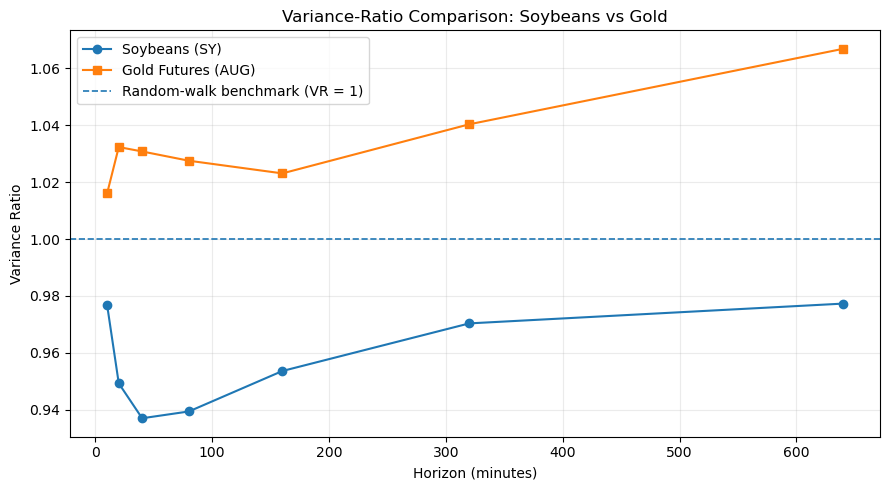

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

sy_plot = sy_vr.dropna(subset=['variance_ratio'])
aug_plot = aug_vr.dropna(subset=['variance_ratio'])

ax.plot(
    sy_plot['horizon_minutes'],
    sy_plot['variance_ratio'],
    marker='o',
    label='Soybeans (SY)'
)

ax.plot(
    aug_plot['horizon_minutes'],
    aug_plot['variance_ratio'],
    marker='s',
    label='Gold Futures (AUG)'
)

ax.axhline(
    y=1.0,
    linestyle='--',
    linewidth=1.2,
    label='Random-walk benchmark (VR = 1)'
)

ax.set_xlabel('Horizon (minutes)')
ax.set_ylabel('Variance Ratio')
ax.set_title('Variance-Ratio Comparison: Soybeans vs Gold')

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 2.6 Interpretation

The variance-ratio results reveal distinct serial-dependence patterns across the two markets.

**Soybeans (SY).** Variance ratios are below 1 across all tested horizons, indicating negative serial dependence. The deviations from the random-walk benchmark are statistically significant at the 5% level from 10 to 160 minutes, with the strongest departure occurring around 40–80 minutes. At longer horizons of 320 and 640 minutes, the variance ratios move back toward 1 and are no longer statistically significant. This suggests that mean-reverting behavior in Soybeans is primarily a short- to intermediate-horizon phenomenon.

**Gold Futures (AUG).** Variance ratios are above 1 across all tested horizons, indicating a directional tendency toward positive serial dependence and momentum. However, none of these deviations are statistically significant at the 5% level. Therefore, the evidence should be interpreted as a trend tendency rather than statistically significant rejection of the random-walk hypothesis.

Overall, the two markets exhibit contrasting intraday dependence structures: Soybeans show statistically significant short-horizon mean reversion, whereas Gold shows a weaker directional tendency toward momentum. These results also highlight the importance of time scale. The short-horizon behavior identified here does not necessarily determine the profitability of the much longer-horizon channel strategy evaluated in the subsequent tasks.

## 3. Push-Response Test

### 3.1 Method

The Push-Response test provides a complementary view of serial dependence by examining how prices behave after unusually large short-horizon return shocks.

A **positive push** is defined as a 5-minute log return above the 90th percentile of the return distribution, while a **negative push** is defined as a return below the 10th percentile.

For each identified push event, cumulative log returns are measured over subsequent horizons of 1 to 128 five-minute bars.

The response is interpreted relative to the direction of the initial push:

- **Continuation:** the subsequent cumulative return moves in the same direction as the initial push, consistent with momentum or trend persistence.
- **Reversal:** the subsequent cumulative return moves against the initial push, consistent with mean reversion.
- **Near-zero response:** little systematic continuation or reversal is observed.

Positive and negative push events are analyzed separately before being combined into a direction-adjusted response measure.

In [11]:
def identify_push_events(
    df: pd.DataFrame,
    pos_q: float = 0.90,
    neg_q: float = 0.10
):
    """
    Identify unusually large positive and negative 5-minute returns.
    """

    r = df['logret'].dropna()

    positive_threshold = r.quantile(pos_q)
    negative_threshold = r.quantile(neg_q)

    positive_events = r[r >= positive_threshold].index.to_numpy()
    negative_events = r[r <= negative_threshold].index.to_numpy()

    return {
        'positive_threshold': positive_threshold,
        'negative_threshold': negative_threshold,
        'positive_events': positive_events,
        'negative_events': negative_events
    }

In [12]:
sy_push = identify_push_events(
    markets['SY'],
    pos_q=POS_Q,
    neg_q=NEG_Q
)

print(
    f"Positive-push threshold: "
    f"{sy_push['positive_threshold']:.6f}"
)

print(
    f"Negative-push threshold: "
    f"{sy_push['negative_threshold']:.6f}"
)

print(
    f"Positive events: "
    f"{len(sy_push['positive_events']):,}"
)

print(
    f"Negative events: "
    f"{len(sy_push['negative_events']):,}"
)

Positive-push threshold: 0.001610
Negative-push threshold: -0.001606
Positive events: 49,577
Negative events: 49,612


### 3.2 Measuring Post-Push Responses

For each push event occurring at time \(t\), the subsequent cumulative log return is measured from \(t+1\) through \(t+h\), where \(h\) denotes the response horizon.

The push return itself is excluded because the objective is to measure the market's **response after the shock**, rather than the magnitude of the shock itself.

Positive and negative pushes are initially evaluated separately. A direction-adjusted response is then constructed so that the interpretation is consistent across both event types:

- positive adjusted response → continuation / momentum;
- negative adjusted response → reversal / mean reversion.

This makes it possible to summarize the post-shock behavior of the market with a common response measure.

In [13]:
def compute_push_responses(
    df: pd.DataFrame,
    event_indices,
    horizons
):
    """
    Compute cumulative log returns after each push event.

    The push bar itself is excluded. For an event at index t,
    the h-bar response is the cumulative log return from
    t+1 through t+h.

    Returns
    -------
    summary : pd.DataFrame
        Summary statistics for each response horizon.

    event_responses : dict
        Raw event-level responses for each horizon.
        These are retained for subsequent statistical inference.
    """

    r = df['logret'].to_numpy()
    n = len(r)

    rows = []
    event_responses = {}

    for h in horizons:
        responses = []

        for idx in event_indices:
            end = idx + h

            # Skip events too close to the end of the sample
            if end >= n:
                continue

            # Future response window: t+1 through t+h
            window = r[idx + 1:end + 1]

            # Require a complete response window
            if np.isnan(window).any():
                continue

            response = np.sum(window)
            responses.append(response)

        responses = np.asarray(responses)

        # Save event-level responses for subsequent inference
        event_responses[h] = responses

        rows.append({
            'horizon_bars': h,
            'horizon_minutes': h * 5,
            'n_events': len(responses),
            'mean_response': np.mean(responses),
            'median_response': np.median(responses),
            'std_response': np.std(responses, ddof=1)
        })

    summary = pd.DataFrame(rows)

    return summary, event_responses

In [14]:
sy_positive_response, sy_positive_events_raw = compute_push_responses(
    markets['SY'],
    sy_push['positive_events'],
    HORIZONS
)

sy_negative_response, sy_negative_events_raw = compute_push_responses(
    markets['SY'],
    sy_push['negative_events'],
    HORIZONS
)

print('Positive Push Responses')
display(sy_positive_response)

print('Negative Push Responses')
display(sy_negative_response)

Positive Push Responses


,horizon_bars,horizon_minutes,n_events,mean_response,median_response,std_response
0,1,5,49577,-0.000098,0.000000,0.003073
1,2,10,49577,-0.000163,-0.000253,0.004002
2,4,20,49577,-0.000188,-0.000256,0.005367
3,8,40,49577,-0.000196,-0.000262,0.007161
4,16,80,49577,-0.000216,-0.000201,0.009621
5,32,160,49577,-0.000316,0.000000,0.013229
6,64,320,49576,-0.000433,0.000000,0.019355
7,128,640,49575,-0.000701,0.000349,0.027321


Negative Push Responses


,horizon_bars,horizon_minutes,n_events,mean_response,median_response,std_response
0,1,5,49612,0.000088,0.000000,0.003329
1,2,10,49612,0.000164,0.000243,0.004289
2,4,20,49612,0.000171,0.000274,0.005518
3,8,40,49612,0.000098,0.000256,0.007248
4,16,80,49612,0.000051,0.000300,0.009659
5,32,160,49612,-0.000124,0.000000,0.013337
6,64,320,49612,-0.000126,0.000489,0.019527
7,128,640,49611,-0.000370,0.000464,0.027257


### 3.3 Direction-Adjusted Response

Because positive and negative shocks have opposite signs, their raw post-push returns cannot be averaged directly.

A direction-adjusted response is therefore defined as

$$
A_h^{+}=R_h^{+}
$$

for positive pushes, and

$$
A_h^{-}=-R_h^{-}
$$

for negative pushes.

Under this transformation:

- $A_h>0$ indicates **continuation / momentum**;
- $A_h<0$ indicates **reversal / mean reversion**.

The average of the positive- and negative-push adjusted responses provides a common measure of post-shock behavior across both event directions.

In [15]:
def combine_push_responses(
    positive_response: pd.DataFrame,
    negative_response: pd.DataFrame
) -> pd.DataFrame:
    """
    Combine positive- and negative-push responses using
    a common direction-adjusted convention.

    adjusted > 0 : continuation / momentum
    adjusted < 0 : reversal / mean reversion
    """

    result = positive_response[
        ['horizon_bars', 'horizon_minutes']
    ].copy()

    result['positive_response'] = (
        positive_response['mean_response'].to_numpy()
    )

    result['negative_response'] = (
        negative_response['mean_response'].to_numpy()
    )

    # Direction-adjust the negative-push response
    result['positive_adjusted'] = (
        result['positive_response']
    )

    result['negative_adjusted'] = (
        -result['negative_response']
    )

    # Equal-weight average of the two push directions
    result['adjusted_response'] = (
        result['positive_adjusted']
        + result['negative_adjusted']
    ) / 2

    result['signal'] = np.where(
        result['adjusted_response'] > 0,
        'continuation',
        np.where(
            result['adjusted_response'] < 0,
            'reversal',
            'neutral'
        )
    )

    return result

In [16]:
sy_pr = combine_push_responses(
    sy_positive_response,
    sy_negative_response
)

sy_pr

,horizon_bars,horizon_minutes,positive_response,negative_response,positive_adjusted,negative_adjusted,adjusted_response,signal
0,1,5,-0.000098,0.000088,-0.000098,-0.000088,-0.000093,reversal
1,2,10,-0.000163,0.000164,-0.000163,-0.000164,-0.000164,reversal
2,4,20,-0.000188,0.000171,-0.000188,-0.000171,-0.000179,reversal
3,8,40,-0.000196,0.000098,-0.000196,-0.000098,-0.000147,reversal
4,16,80,-0.000216,0.000051,-0.000216,-0.000051,-0.000134,reversal
5,32,160,-0.000316,-0.000124,-0.000316,0.000124,-0.000096,reversal
6,64,320,-0.000433,-0.000126,-0.000433,0.000126,-0.000153,reversal
7,128,640,-0.000701,-0.000370,-0.000701,0.000370,-0.000166,reversal


In [17]:
def response_inference(responses: np.ndarray) -> dict:
    """
    Compute descriptive inference for event-level post-push responses.

    Note:
    Response windows may overlap across nearby push events, so the
    resulting confidence intervals should be interpreted as descriptive
    statistical evidence rather than inference from fully independent
    observations.
    """

    x = np.asarray(responses)
    x = x[np.isfinite(x)]

    n = len(x)

    if n < 2:
        return {
            'mean': np.nan,
            'std': np.nan,
            'se': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan
        }

    mean = np.mean(x)
    std = np.std(x, ddof=1)
    se = std / np.sqrt(n)

    ci_lower = mean - 1.96 * se
    ci_upper = mean + 1.96 * se

    return {
        'mean': mean,
        'std': std,
        'se': se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }

### 3.4 Approximate Statistical Inference

The sign of the average post-push response indicates whether market behavior is characterized by continuation or reversal, but the sign alone does not establish statistical reliability.

For each response horizon, an approximate 95% confidence interval is constructed around the mean event-level response using

$$
\bar{x} \pm 1.96 \times SE(\bar{x}),
$$

where

$$
SE(\bar{x})=\frac{s}{\sqrt{n}}.
$$

The intervals provide a descriptive indication of whether the average response is clearly separated from zero:

- an interval entirely below zero supports a negative average response;
- an interval entirely above zero supports a positive average response;
- an interval containing zero indicates an inconclusive directional response.

Because push events can occur close together and their future response windows may overlap, the event-level observations are not fully independent. Therefore, these confidence intervals should be interpreted as **approximate descriptive statistical evidence**, rather than as formal inference under independent observations.

In [18]:
def build_push_inference_table(
    positive_raw: dict,
    negative_raw: dict,
    horizons
) -> pd.DataFrame:
    """
    Build horizon-by-horizon inference results for
    positive and negative push responses.
    """

    rows = []

    for h in horizons:
        pos = response_inference(positive_raw[h])
        neg = response_inference(negative_raw[h])

        rows.append({
            'horizon_bars': h,
            'horizon_minutes': h * 5,

            'positive_mean': pos['mean'],
            'positive_ci_lower': pos['ci_lower'],
            'positive_ci_upper': pos['ci_upper'],

            'negative_mean': neg['mean'],
            'negative_ci_lower': neg['ci_lower'],
            'negative_ci_upper': neg['ci_upper']
        })

    return pd.DataFrame(rows)

In [19]:
sy_pr_inference = build_push_inference_table(
    sy_positive_events_raw,
    sy_negative_events_raw,
    HORIZONS
)

sy_pr_inference

,horizon_bars,horizon_minutes,positive_mean,positive_ci_lower,positive_ci_upper,negative_mean,negative_ci_lower,negative_ci_upper
0,1,5,-0.000098,-0.000125,-0.000071,0.000088,0.000059,0.000117
1,2,10,-0.000163,-0.000198,-0.000128,0.000164,0.000126,0.000202
2,4,20,-0.000188,-0.000235,-0.000141,0.000171,0.000122,0.000219
3,8,40,-0.000196,-0.000259,-0.000133,0.000098,0.000034,0.000162
4,16,80,-0.000216,-0.000301,-0.000132,0.000051,-0.000034,0.000136
5,32,160,-0.000316,-0.000432,-0.000199,-0.000124,-0.000241,-0.000006
6,64,320,-0.000433,-0.000604,-0.000263,-0.000126,-0.000298,0.000045
7,128,640,-0.000701,-0.000942,-0.000461,-0.000370,-0.000610,-0.000130


### 3.5 Soybean Push-Response Results

The post-push responses reveal an asymmetric pattern between positive and negative shocks.

Positive price shocks are followed by negative average returns across all tested horizons, indicating a persistent tendency toward reversal. Negative shocks, by contrast, are followed by positive returns at shorter horizons, but this reversal weakens and changes direction at longer horizons.

The confidence intervals shown below are approximate and should be interpreted as descriptive statistical evidence because response windows from nearby push events may overlap.

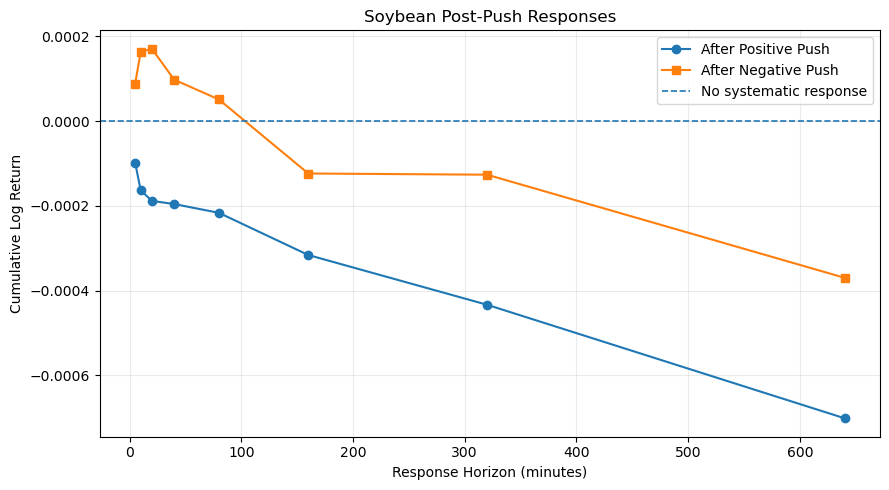

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

x = sy_pr_inference['horizon_minutes']

# Positive-push mean response
ax.plot(
    x,
    sy_pr_inference['positive_mean'],
    marker='o',
    label='After Positive Push'
)

# Negative-push mean response
ax.plot(
    x,
    sy_pr_inference['negative_mean'],
    marker='s',
    label='After Negative Push'
)

# Zero-response benchmark
ax.axhline(
    y=0,
    linestyle='--',
    linewidth=1.2,
    label='No systematic response'
)

ax.set_xlabel('Response Horizon (minutes)')
ax.set_ylabel('Cumulative Log Return')
ax.set_title('Soybean Post-Push Responses')

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 3.6 Gold Futures Push-Response Results

The same Push-Response methodology is applied to Gold Futures (AUG) using the same 90th/10th percentile definitions, response horizons, and inference procedures.

This allows the post-shock dynamics of Soybeans and Gold to be compared using a consistent framework.

In [21]:
aug_push = identify_push_events(
    markets['AUG'],
    pos_q=POS_Q,
    neg_q=NEG_Q
)

print(
    f"Positive-push threshold: "
    f"{aug_push['positive_threshold']:.6f}"
)

print(
    f"Negative-push threshold: "
    f"{aug_push['negative_threshold']:.6f}"
)

print(
    f"Positive events: "
    f"{len(aug_push['positive_events']):,}"
)

print(
    f"Negative events: "
    f"{len(aug_push['negative_events']):,}"
)

Positive-push threshold: 0.000405
Negative-push threshold: -0.000375
Positive events: 13,876
Negative events: 13,875


In [22]:
aug_positive_response, aug_positive_events_raw = compute_push_responses(
    markets['AUG'],
    aug_push['positive_events'],
    HORIZONS
)

aug_negative_response, aug_negative_events_raw = compute_push_responses(
    markets['AUG'],
    aug_push['negative_events'],
    HORIZONS
)

print('Positive Push Responses')
display(aug_positive_response)

print('Negative Push Responses')
display(aug_negative_response)

Positive Push Responses


,horizon_bars,horizon_minutes,n_events,mean_response,median_response,std_response
0,1,5,13876,0.000028,0.000000,0.002104
1,2,10,13876,0.000063,0.000000,0.002641
2,4,20,13876,0.000080,0.000000,0.003664
3,8,40,13876,0.000162,0.000000,0.004994
4,16,80,13876,0.000253,0.000044,0.006888
5,32,160,13875,0.000312,0.000142,0.007860
6,64,320,13870,0.000395,0.000348,0.011329
7,128,640,13857,0.000812,0.001073,0.016584


Negative Push Responses


,horizon_bars,horizon_minutes,n_events,mean_response,median_response,std_response
0,1,5,13875,0.000007,0.000026,0.001721
1,2,10,13875,-0.000007,0.000035,0.002671
2,4,20,13874,0.000005,0.000053,0.003716
3,8,40,13873,0.000038,0.000098,0.005182
4,16,80,13870,0.000143,0.000151,0.007537
5,32,160,13870,0.000177,0.000217,0.008248
6,64,320,13864,0.000224,0.000354,0.011654
7,128,640,13851,0.000747,0.001188,0.017149


In [23]:
aug_pr = combine_push_responses(
    aug_positive_response,
    aug_negative_response
)

aug_pr

,horizon_bars,horizon_minutes,positive_response,negative_response,positive_adjusted,negative_adjusted,adjusted_response,signal
0,1,5,0.000028,0.000007,0.000028,-0.000007,0.000011,continuation
1,2,10,0.000063,-0.000007,0.000063,0.000007,0.000035,continuation
2,4,20,0.000080,0.000005,0.000080,-0.000005,0.000038,continuation
3,8,40,0.000162,0.000038,0.000162,-0.000038,0.000062,continuation
4,16,80,0.000253,0.000143,0.000253,-0.000143,0.000055,continuation
5,32,160,0.000312,0.000177,0.000312,-0.000177,0.000067,continuation
6,64,320,0.000395,0.000224,0.000395,-0.000224,0.000085,continuation
7,128,640,0.000812,0.000747,0.000812,-0.000747,0.000033,continuation


In [24]:
aug_pr_inference = build_push_inference_table(
    aug_positive_events_raw,
    aug_negative_events_raw,
    HORIZONS
)

aug_pr_inference

,horizon_bars,horizon_minutes,positive_mean,positive_ci_lower,positive_ci_upper,negative_mean,negative_ci_lower,negative_ci_upper
0,1,5,0.000028,-0.000007,0.000063,0.000007,-0.000022,0.000035
1,2,10,0.000063,0.000019,0.000107,-0.000007,-0.000052,0.000037
2,4,20,0.000080,0.000019,0.000141,0.000005,-0.000057,0.000067
3,8,40,0.000162,0.000079,0.000245,0.000038,-0.000048,0.000124
4,16,80,0.000253,0.000139,0.000368,0.000143,0.000018,0.000269
5,32,160,0.000312,0.000181,0.000442,0.000177,0.000040,0.000315
6,64,320,0.000395,0.000206,0.000583,0.000224,0.000030,0.000418
7,128,640,0.000812,0.000536,0.001088,0.000747,0.000461,0.001032


The Gold Push-Response results reveal a pronounced asymmetry between positive and negative price shocks.

Positive shocks are followed by positive average returns across the tested horizons, with the continuation tendency becoming stronger as the response horizon increases. Negative shocks, however, do not exhibit a symmetric continuation pattern. At longer horizons, they are followed by positive average returns, indicating reversal after downward shocks.

The approximate confidence intervals provide descriptive evidence of these patterns but should be interpreted cautiously because response windows from nearby push events may overlap.

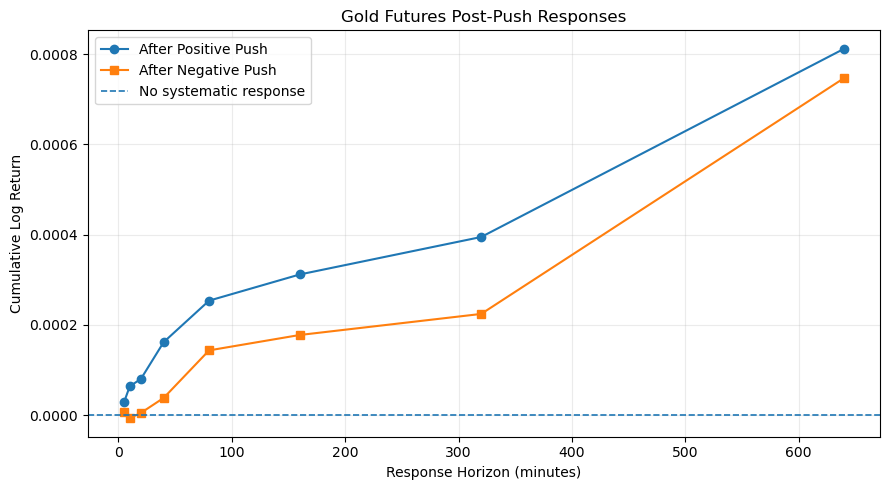

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

x = aug_pr_inference['horizon_minutes']

ax.plot(
    x,
    aug_pr_inference['positive_mean'],
    marker='o',
    label='After Positive Push'
)

ax.plot(
    x,
    aug_pr_inference['negative_mean'],
    marker='s',
    label='After Negative Push'
)

ax.axhline(
    y=0,
    linestyle='--',
    linewidth=1.2,
    label='No systematic response'
)

ax.set_xlabel('Response Horizon (minutes)')
ax.set_ylabel('Cumulative Log Return')
ax.set_title('Gold Futures Post-Push Responses')

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 3.7 Cross-Market Comparison

To compare the two markets directly, positive- and negative-push responses are converted into a common direction-adjusted measure.

Under this convention, a positive adjusted response indicates continuation in the direction of the initial shock, while a negative adjusted response indicates reversal.

The comparison therefore summarizes the dominant post-shock tendency of each market across the same response horizons. Because positive and negative shocks can exhibit asymmetric behavior, the combined measure should be interpreted together with the direction-specific results presented above.

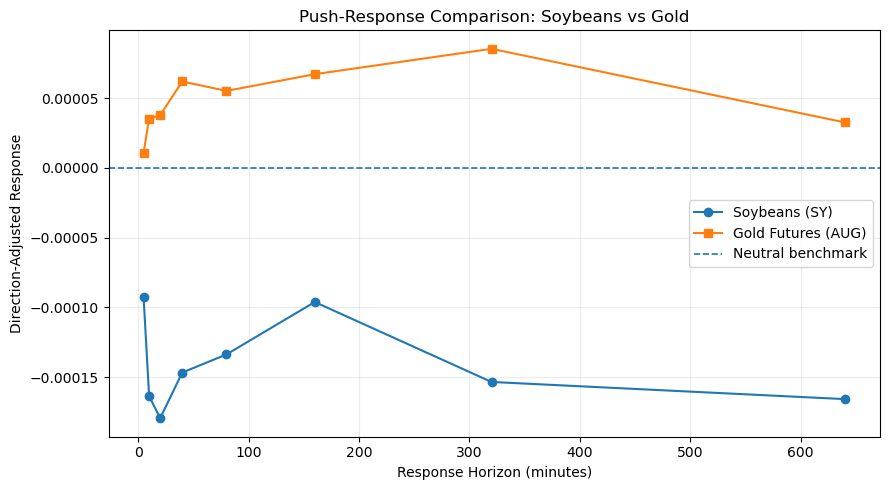

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    sy_pr['horizon_minutes'],
    sy_pr['adjusted_response'],
    marker='o',
    label='Soybeans (SY)'
)

ax.plot(
    aug_pr['horizon_minutes'],
    aug_pr['adjusted_response'],
    marker='s',
    label='Gold Futures (AUG)'
)

ax.axhline(
    y=0,
    linestyle='--',
    linewidth=1.2,
    label='Neutral benchmark'
)

ax.set_xlabel('Response Horizon (minutes)')
ax.set_ylabel('Direction-Adjusted Response')
ax.set_title('Push-Response Comparison: Soybeans vs Gold')

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 3.8 Interpretation

The Push-Response analysis reveals distinct and asymmetric post-shock dynamics across the two markets.

**Soybeans (SY).** The direction-adjusted response is negative across all tested horizons, indicating an overall tendency toward post-shock reversal. The direction-specific results show that this pattern is particularly persistent following positive shocks: large upward moves are followed by negative average returns across the full range of horizons. Negative shocks exhibit short-horizon reversal as well, although this behavior weakens and becomes less stable at longer horizons.

**Gold Futures (AUG).** The direction-adjusted response is positive across all tested horizons, indicating an overall continuation tendency. However, the direction-specific results reveal substantial asymmetry. Positive shocks are followed by increasingly positive average returns, providing the clearest evidence of momentum-like behavior. Negative shocks do not exhibit a symmetric continuation pattern and are generally followed by positive returns at longer horizons, indicating reversal after downward shocks.

Taken together, the Push-Response results complement the Variance-Ratio analysis. Soybeans display stronger evidence of short-horizon mean-reverting behavior, whereas Gold exhibits a weaker unconditional momentum tendency in the Variance-Ratio test but clearer conditional continuation following large positive shocks. The difference between the two tests is economically meaningful: the Variance-Ratio test evaluates dependence in the overall return process, while the Push-Response analysis conditions specifically on unusually large price movements.

These findings characterize short- to intermediate-horizon market behavior and should not be interpreted as direct evidence for or against the profitability of the much longer-horizon channel strategy evaluated in the subsequent tasks.

## 4. Final Summary

The table below summarizes the main findings from the Variance-Ratio and Push-Response analyses for both markets.

In [27]:
summary_table = pd.DataFrame({
    'Market': [
        'Soybeans (SY)',
        'Gold Futures (AUG)'
    ],
    
    'VR Pattern': [
        'VR < 1',
        'VR > 1'
    ],
    
    'VR Interpretation': [
        'Mean-reversion tendency',
        'Momentum tendency'
    ],
    
    'VR Statistical Evidence': [
        'Significant at short/intermediate horizons',
        'Not significant at 5% level'
    ],
    
    'Push-Response Pattern': [
        'Overall reversal',
        'Overall continuation'
    ],
    
    'Push-Response Asymmetry': [
        'Persistent reversal after positive shocks; negative-shock reversal weakens at longer horizons',
        'Strong continuation after positive shocks; negative shocks show longer-horizon reversal'
    ],
    
    'Overall Interpretation': [
        'Stronger short-horizon mean-reverting behavior',
        'Weaker unconditional momentum, but clearer conditional positive-shock continuation'
    ]
})

summary_table

,Market,VR Pattern,VR Interpretation,VR Statistical Evidence,Push-Response Pattern,Push-Response Asymmetry,Overall Interpretation
0,Soybeans (SY),VR < 1,Mean-reversion tendency,Significant at short/intermediate horizons,Overall reversal,Persistent reversal after positive shocks; neg...,Stronger short-horizon mean-reverting behavior
1,Gold Futures (AUG),VR > 1,Momentum tendency,Not significant at 5% level,Overall continuation,Strong continuation after positive shocks; neg...,"Weaker unconditional momentum, but clearer con..."


## 5. Export Results

The main statistical results are exported for reproducibility and for use in subsequent analysis and reporting.

In [28]:
# Save Variance-Ratio results
sy_vr.to_csv(OUT_DIR / 'SY_variance_ratio.csv', index=False)
aug_vr.to_csv(OUT_DIR / 'AUG_variance_ratio.csv', index=False)

# Save Push-Response results
sy_pr.to_csv(OUT_DIR / 'SY_push_response.csv', index=False)
aug_pr.to_csv(OUT_DIR / 'AUG_push_response.csv', index=False)

# Save Push-Response inference tables
sy_pr_inference.to_csv(
    OUT_DIR / 'SY_push_response_inference.csv',
    index=False
)

aug_pr_inference.to_csv(
    OUT_DIR / 'AUG_push_response_inference.csv',
    index=False
)

# Save final cross-market summary
summary_table.to_csv(
    OUT_DIR / 'random_walk_summary.csv',
    index=False
)

print('Saved Task 3 outputs to:')
print(OUT_DIR.resolve())

Saved Task 3 outputs to:
/Users/apple/Desktop/期货市场趋势跟踪策略的量化分析与滚动回测/数据/task3_outputs
